In [1]:
import pandas as pd
from pathlib import Path

# Load the raw data from CSVs.
base_path = Path("pr_curves")
all_pr_data = []
for csv_path in base_path.iterdir():
    pr_data = pd.read_csv(csv_path)
    # Set the name to something reasonable.
    name = csv_path.stem.replace("_", " ").title()
    name = name.replace("Moco", "MoCo")
    name = name.replace("Simclr", "SimCLR")
    name = name.replace("Coco", "COCO")
    pr_data["name"] = name
    all_pr_data.append(pr_data)
    
all_pr_data = pd.concat(all_pr_data)

# Give the columns better names and remove unused ones.
all_pr_data = all_pr_data[["x", "y", "name"]]
all_pr_data.rename({"x": "Recall", "y": "Precision", "name": "Pre-Training"}, axis="columns", inplace=True)

# Separate into MoCo and SimCLR
pre_training = all_pr_data["Pre-Training"]
moco_pr_data = all_pr_data[pre_training.str.contains("MoCo") | (pre_training == "COCO")]
simclr_pr_data = all_pr_data[pre_training.str.contains("SimCLR") | (pre_training == "COCO")]

all_pr_data

,Recall,Precision,Pre-Training
0,0.00,1.000,SimCLR Vanilla
1,0.01,1.000,SimCLR Vanilla
2,0.02,0.999,SimCLR Vanilla
3,0.03,0.998,SimCLR Vanilla
4,0.04,0.997,SimCLR Vanilla
...,...,...,...
195,0.96,0.054,MoCo Vanilla
196,0.97,0.041,MoCo Vanilla
197,0.98,0.027,MoCo Vanilla
198,0.99,0.014,MoCo Vanilla


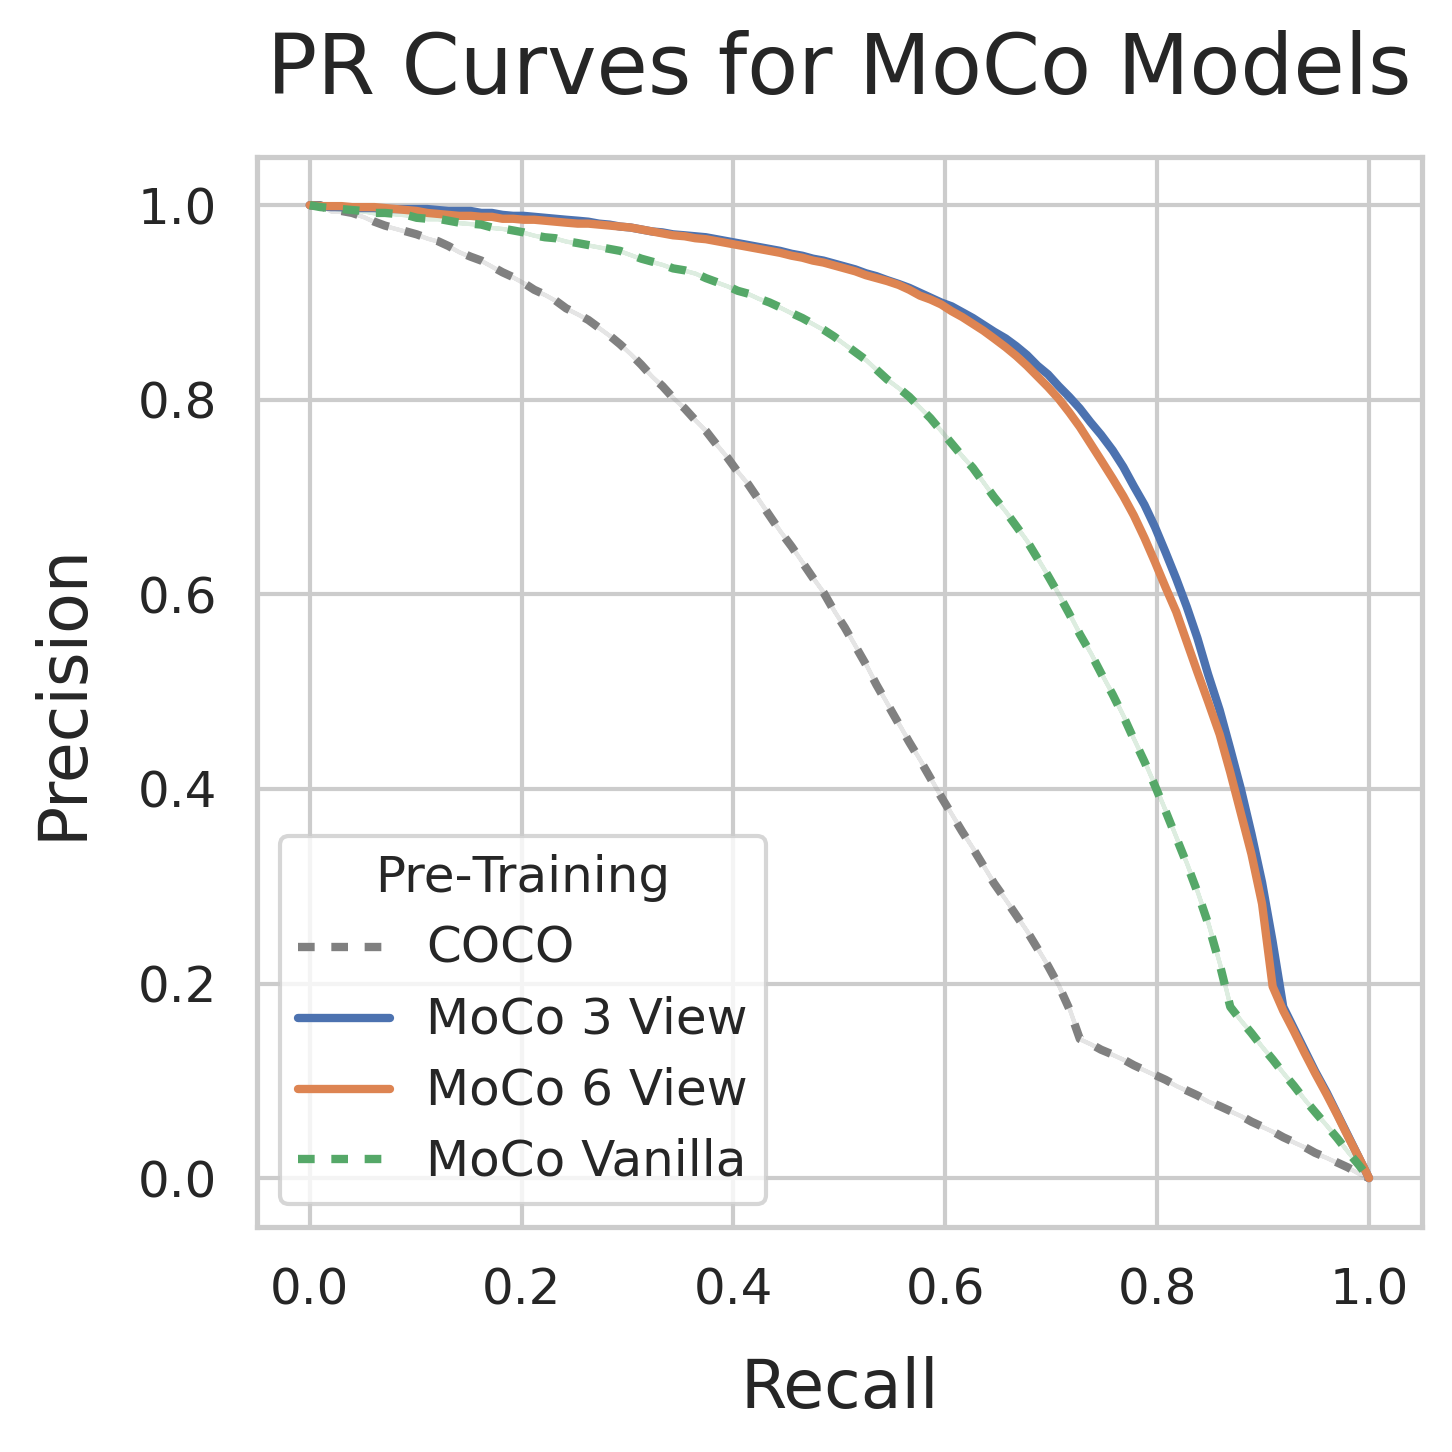

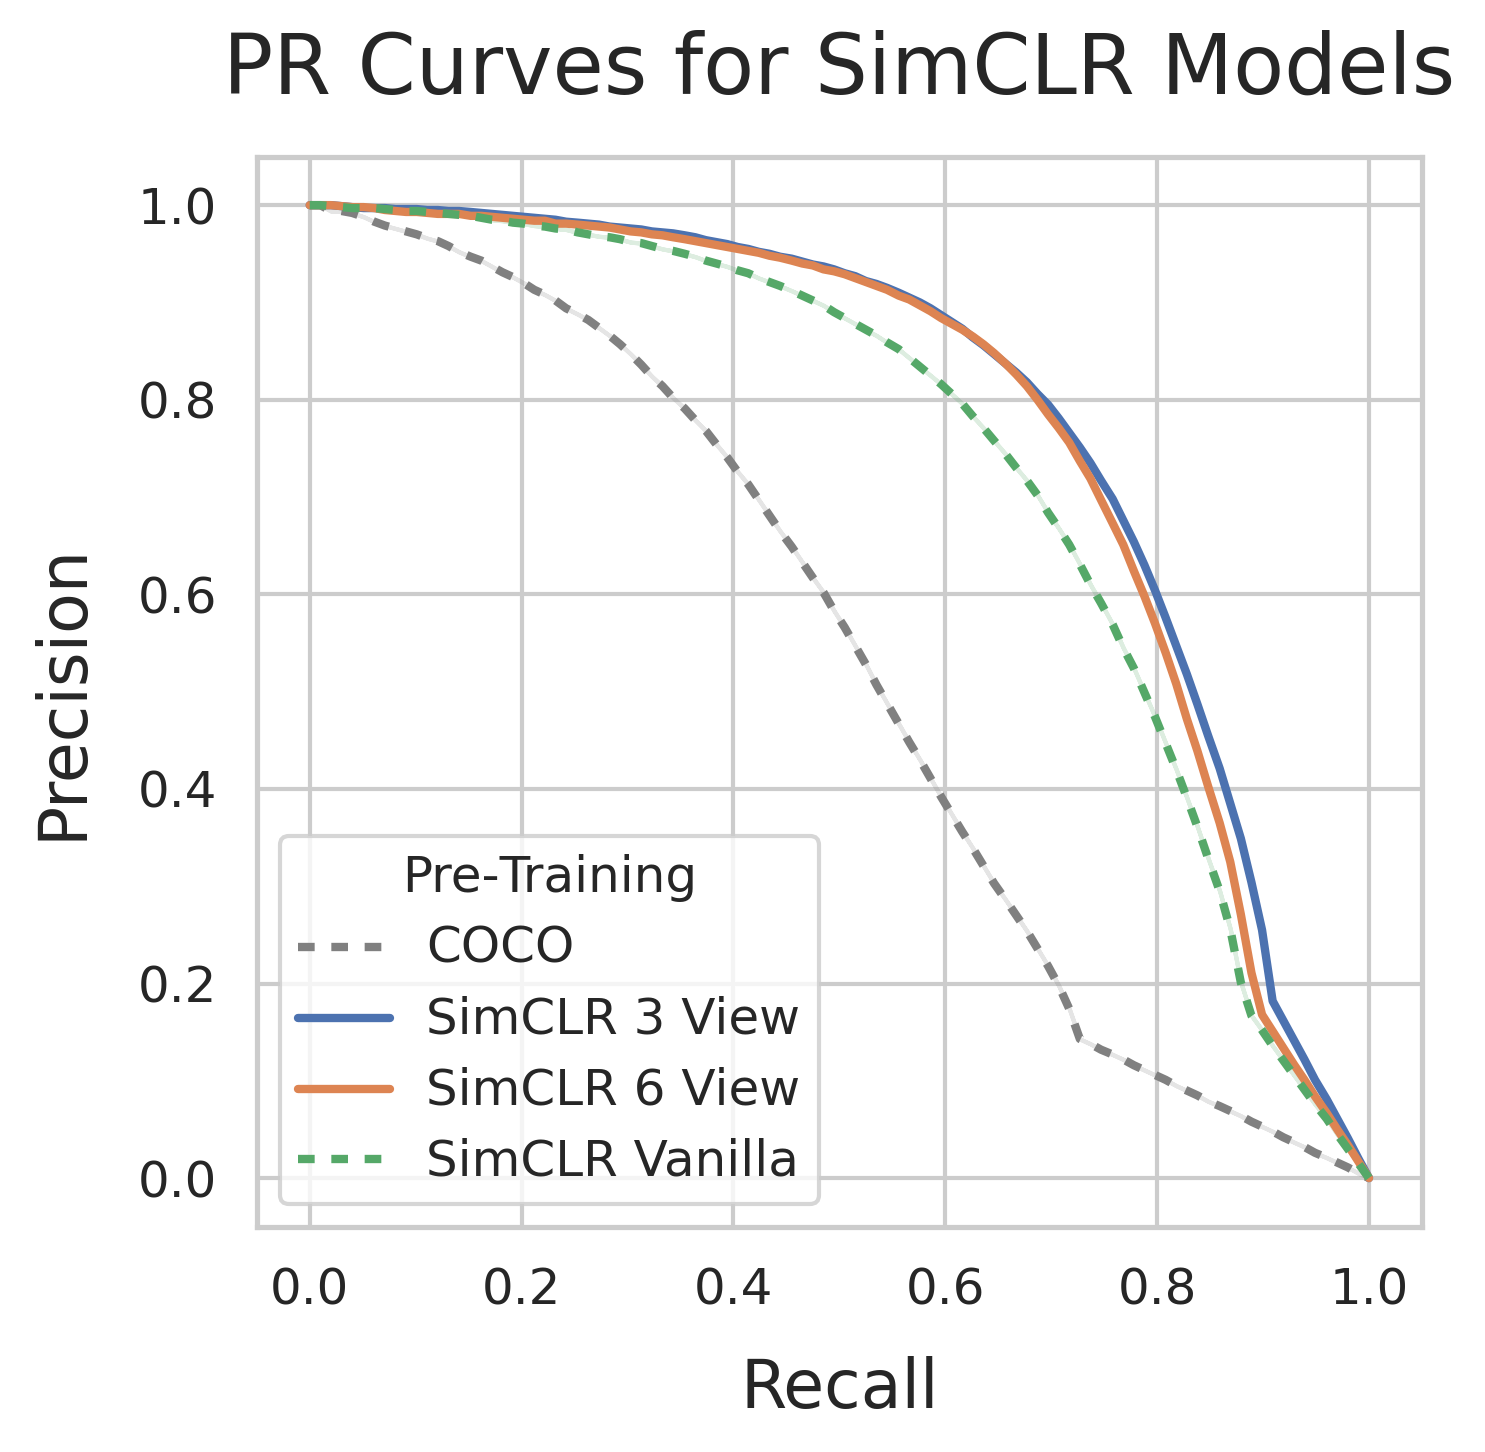

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

def draw_pr_curve(pr_data, title="Precision‑Recall Curves"):
    """
    Plot Precision vs Recall.
    - Alphabetical legend.
    - Lines containing “COCO” are gray and dotted.
    - Lines containing “Vanilla” are dotted (default colour).
    - All other lines are solid with the default seaborn palette.
    - Font sizes are hard‑coded:
        • title      → 20 pt
        • axis labels → 16 pt
        • tick labels → 12 pt
        • legend text → 12 pt
    """
    # ------------------------------------------------------------------
    # 1️⃣  Alphabetical ordering of the hue categories
    # ------------------------------------------------------------------
    hue_vals = sorted(pr_data["Pre-Training"].unique())

    # ------------------------------------------------------------------
    # 2️⃣  Colour map
    # ------------------------------------------------------------------
    palette = {}
    default_colors = sns.color_palette(n_colors=len(hue_vals))
    default_idx = 0
    for label in hue_vals:
        if "COCO" in label:
            palette[label] = "gray"
        else:
            palette[label] = default_colors[default_idx]
            default_idx += 1

    # ------------------------------------------------------------------
    # 3️⃣  Dash‑style map
    #    * “COCO” or “Vanilla” → dotted (2, 2)
    #    * everything else      → solid (empty string)
    # ------------------------------------------------------------------
    dashes = {}
    for label in hue_vals:
        if ("COCO" in label) or ("Vanilla" in label):
            dashes[label] = (2, 2)          # dotted
        else:
            dashes[label] = ""              # solid line

    # ------------------------------------------------------------------
    # 4️⃣  Plot
    # ------------------------------------------------------------------
    sns.set(style="whitegrid")
    plt.figure(figsize=(5, 5), dpi=300)

    ax = sns.lineplot(
        data=pr_data,
        x="Recall",
        y="Precision",
        hue="Pre-Training",
        style="Pre-Training",      # needed so Seaborn respects our dashes dict
        hue_order=hue_vals,
        palette=palette,
        dashes=dashes,
        linewidth=2,
        # marker="o"               # uncomment if you want markers
    )

    # ---------- Title ----------
    ax.set_title(title, fontsize=20, pad=15)   # title size = 20 pt

    # ---------- Axis labels ----------
    ax.set_xlabel("Recall", fontsize=16, labelpad=10)     # x‑label size = 16 pt
    ax.set_ylabel("Precision", fontsize=16, labelpad=10) # y‑label size = 16 pt

    # ---------- Tick labels ----------
    ax.tick_params(axis='both', which='major', labelsize=12)   # tick size = 12 pt

    # ---------- Legend ----------
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Pre‑Training", prop={'size': 12})   # legend title size
        for txt in legend.get_texts():
            txt.set_fontsize(12)                              # legend entry size
        # optional: push legend a little outside the plot
        #legend.set_bbox_to_anchor((0.7, 1))
        legend.set_frame_on(True)

    plt.tight_layout()
    plt.show()
    
draw_pr_curve(moco_pr_data, title="PR Curves for MoCo Models")
draw_pr_curve(simclr_pr_data, title="PR Curves for SimCLR Models")